# Part 15 — nnPU follow-up, Zadanie 4: masking-protocol robustness

Tests the core motivation for nnPU directly: does its non-negative-corrected risk
degrade *less* than plain BCE when a fraction of true positives are deliberately
hidden from training (simulating a harder positive-unlabeled scenario), compared to
the same bce-vs-nnpu gap without masking? This campaign (`kidney-nnpu-masked30`) was
blocked earlier in this project (never submitted for training) and has since
completed — this is that analysis.

Four variants, two axes: head loss (`bce` balanced vs. `nnpu`) x train-set masking
(none vs. 30% of train positives masked to unlabeled, `seed=314159`), all four
otherwise identical (`+contractive +peak_label_invariant` regularizers, same
architecture, same 5 repetitions). `0004`/`0006` are the existing unmasked pair
(`kidney-architecture-predictive`); `0004_masked30`/`0006_masked30` are the new
masked pair (`kidney-nnpu-masked30`).

**Standing rules from this project's methodology, followed throughout**: never
compare BCE vs. nnPU raw loss values directly (different functional forms, not
comparable); never report `‖J‖_F` as a flatness measure; always check any
between-variant difference against its own seed-to-seed (repetition) null before
trusting it.


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.heads.metrics import evaluate_head, per_class_metrics, probabilities_from_logits
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

2026-08-28 02:16:03,997 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 02:16:04,002 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-28 02:16:04,846 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-28 02:16:04,847 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-28 02:16:04,849 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-28 02:16:04,850 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 02:16:04,869 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-28 02:16:05,000 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-28 02:16:05,001 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"

UNMASKED_CAMPAIGN = "kidney-architecture-predictive__cfg_529dc0e4494b"
MASKED_CAMPAIGN = "kidney-nnpu-masked30__cfg_5c63c9c8e1d1"

# Verified directly against each variant's config.json -- not reconstructed from
# memory. Masking spec (both masked variants, confirmed identical):
# annotation_settings.targets.molecule.train_positive_mask = {fraction: 0.3, seed: 314159}.
VARIANT_SPECS = {
    "0004": (UNMASKED_CAMPAIGN, "grid_0004"),
    "0006": (UNMASKED_CAMPAIGN, "grid_0006"),
    "0004_masked30": (MASKED_CAMPAIGN, "grid_0000"),
    "0006_masked30": (MASKED_CAMPAIGN, "grid_0001"),
}
HEAD_FAMILY = {"0004": "bce", "0006": "nnpu", "0004_masked30": "bce", "0006_masked30": "nnpu"}
IS_MASKED = {"0004": False, "0006": False, "0004_masked30": True, "0006_masked30": True}
VARIANT_DESCRIPTIONS = {
    "0004": "bce (balanced, pos_weight), +contractive +peak_label_invariant, unmasked train",
    "0006": "nnpu (prior x1.5), +contractive +peak_label_invariant, unmasked train",
    "0004_masked30": "bce (balanced, pos_weight), +contractive +peak_label_invariant, 30% of train positives masked (seed 314159)",
    "0006_masked30": "nnpu (prior x1.5), +contractive +peak_label_invariant, 30% of train positives masked (seed 314159)",
}
VARIANT_SHORT_LABELS = {
    "0004": "0004: bce, unmasked",
    "0006": "0006: nnpu, unmasked",
    "0004_masked30": "0004m: bce, masked30",
    "0006_masked30": "0006m: nnpu, masked30",
}

REPETITIONS = range(5)
HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
THRESHOLD = 0.5
BATCH_SIZE = 256

RESULTS_DIRECTORY = Path("assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results")
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

theme = resolve_theme(None)
theme.apply()
model_colors = {variant: theme.color_for_model(variant, index) for index, variant in enumerate(VARIANT_SPECS)}
from dataclasses import replace
theme = replace(theme, model_overrides=model_colors)
theme.apply()

## Environment workaround

In [3]:
SCRATCH_ROOTS = [
    "/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-masked30-20260827/workspace",
]
for scratch_root in SCRATCH_ROOTS:
    path = Path(scratch_root)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.is_symlink():
        path.symlink_to(WORKSPACE.resolve())

## What each variant actually is

### Methodology
#### Theoretical
- Same rationale as `part_14`'s equivalent table: every later plot refers to
  variants by grid code alone, which says nothing about what differs. Here the
  critical distinction (masked vs. unmasked train) is the entire point of the
  notebook, so it needs to be unmistakable everywhere, not just in this table.

#### Implementation
- Built from `VARIANT_SPECS`/`VARIANT_DESCRIPTIONS`, the latter verified against
  each variant's actual `config.json`.

### Notes


In [4]:
pd.DataFrame([
    {
        "variant": variant, "campaign": campaign_id, "grid_id": grid_id,
        "head_family": HEAD_FAMILY[variant], "masked": IS_MASKED[variant],
        "description": VARIANT_DESCRIPTIONS[variant],
    }
    for variant, (campaign_id, grid_id) in VARIANT_SPECS.items()
]).set_index("variant")

,campaign,grid_id,head_family,masked,description
variant,,,,,
0004,kidney-architecture-predictive__cfg_529dc0e4494b,grid_0004,bce,False,"bce (balanced, pos_weight), +contractive +peak..."
0006,kidney-architecture-predictive__cfg_529dc0e4494b,grid_0006,nnpu,False,"nnpu (prior x1.5), +contractive +peak_label_in..."
0004_masked30,kidney-nnpu-masked30__cfg_5c63c9c8e1d1,grid_0000,bce,True,"bce (balanced, pos_weight), +contractive +peak..."
0006_masked30,kidney-nnpu-masked30__cfg_5c63c9c8e1d1,grid_0001,nnpu,True,"nnpu (prior x1.5), +contractive +peak_label_in..."


## Load every (variant, repetition): test-split logits, train positive counts per campaign

### Methodology
#### Theoretical
- Masking is applied only to the `train` split's positive labels (the config key is
  literally `train_positive_mask`); `test` should be completely untouched and
  identical across the masked and unmasked campaigns, since both are the same
  underlying `kidney` dataset with the same `seed=42` predefined split. This is
  verified explicitly below rather than assumed — if it were not true, every
  comparison in this notebook would be invalid.

#### Implementation
- For each `(variant, repetition)`: load the model (first variant of each campaign
  via `load_configuration`, the rest via the lightweight `models_manager.load_model`
  swap), run inference on `test`, keep the raw logits. `train`/`test`
  targets+masks are collected once per campaign (not per repetition, since they do
  not depend on model weights) via `collect_targets_and_masks`.
- Pipeline check: `test` targets/mask arrays are compared byte-for-byte
  (`np.array_equal`) between the two campaigns — printed below.

### Notes


In [5]:
def collect_targets_and_masks(dataset) -> tuple[np.ndarray, np.ndarray]:
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    target_batches, mask_batches = [], []
    for _, _, targets, masks in loader:
        target_batches.append(targets[TARGET_FIELD].numpy())
        mask_batches.append(masks[TARGET_FIELD].numpy())
    return np.concatenate(target_batches, axis=0), np.concatenate(mask_batches, axis=0)


wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

loaded_campaign_ids: set[str] = set()
train_targets_masks_by_campaign: dict[str, tuple[np.ndarray, np.ndarray]] = {}
test_targets_masks_by_campaign: dict[str, tuple[np.ndarray, np.ndarray]] = {}
results: dict[tuple[str, int], dict] = {}

for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    for repetition in REPETITIONS:
        model_name = f"{campaign_id}__{grid_id}__rep_0{repetition}"
        if campaign_id not in loaded_campaign_ids:
            wrapper.load_configuration(model_name=model_name)
            loaded_campaign_ids.add(campaign_id)
            model = wrapper.active_model
        else:
            model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        device = next(model.parameters()).device
        partitions = wrapper.active_dataset.create_partitions()

        if campaign_id not in train_targets_masks_by_campaign:
            train_targets_masks_by_campaign[campaign_id] = collect_targets_and_masks(partitions.train)
        if campaign_id not in test_targets_masks_by_campaign:
            test_targets_masks_by_campaign[campaign_id] = collect_targets_and_masks(partitions.test)
        test_targets, test_mask = test_targets_masks_by_campaign[campaign_id]

        logits_chunks = []
        loader = DataLoader(partitions.test, batch_size=BATCH_SIZE, shuffle=False)
        with torch.no_grad():
            for _, spectra, _, _ in loader:
                logits_chunks.append(model(spectra.float().to(device))[f"head_{HEAD_NAME}"].cpu().numpy())
        logits = np.concatenate(logits_chunks, axis=0)
        results[(variant, repetition)] = {"logits": logits, "targets": test_targets, "mask": test_mask}
    print(f"{variant}: done")

campaign_ids = list(test_targets_masks_by_campaign)
test_targets_match = np.array_equal(test_targets_masks_by_campaign[campaign_ids[0]][0], test_targets_masks_by_campaign[campaign_ids[1]][0])
test_mask_match = np.array_equal(test_targets_masks_by_campaign[campaign_ids[0]][1], test_targets_masks_by_campaign[campaign_ids[1]][1])
print(f"test targets identical across campaigns: {test_targets_match}")
print(f"test mask identical across campaigns: {test_mask_match}")

2026-08-28 02:16:05,223 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-28 02:16:05,225 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-28 02:16:05,226 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-28 02:16:05,227 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 02:16:05,227 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-28 02:21:01,157 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-28 02:21:01,158 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-28 02:21:01,161 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 02:21:01,165 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


0006_masked30: done
test targets identical across campaigns: True
test mask identical across campaigns: True


## Class coverage: does 30% train-positive masking shrink the train-active class set?

### Methodology
#### Theoretical
- Masking removes 30% of train positives uniformly at random (fixed seed). A class
  that had very few positive train pixels to begin with could plausibly lose *all*
  of them, dropping out of the train-active set entirely — this would mean the
  masked models have strictly less to learn from than just "30% noisier," for at
  least some classes. Checked directly rather than assumed.

#### Implementation
- Per campaign: `train_active_class_mask = (train_targets * train_mask).sum(axis=0) > 0`.
  Compared between the masked and unmasked campaign, plus the fair scope
  (`train_active ∩ test_active`, `test_active` shared across both since `test` is
  identical) for each.

### Notes


In [6]:
test_positive_count_per_class = (test_targets_masks_by_campaign[campaign_ids[0]][0] * test_targets_masks_by_campaign[campaign_ids[0]][1]).sum(axis=0)
test_active_class_mask = test_positive_count_per_class > 0

train_active_by_campaign = {}
coverage_rows = []
for campaign_id in campaign_ids:
    train_targets, train_mask = train_targets_masks_by_campaign[campaign_id]
    active_mask = (train_targets * train_mask).sum(axis=0) > 0
    train_active_by_campaign[campaign_id] = active_mask
    fair_mask = active_mask & test_active_class_mask
    coverage_rows.append({
        "campaign": campaign_id, "masked": campaign_id == MASKED_CAMPAIGN,
        "train_active_classes": int(active_mask.sum()),
        "train_active_and_test_active": int(fair_mask.sum()),
    })

coverage_frame = pd.DataFrame(coverage_rows)
lost_classes = train_active_by_campaign[UNMASKED_CAMPAIGN] & ~train_active_by_campaign[MASKED_CAMPAIGN]
print(f"classes with train positives unmasked but zero after masking: {int(lost_classes.sum())}")
coverage_frame

classes with train positives unmasked but zero after masking: 0


,campaign,masked,train_active_classes,train_active_and_test_active
0,kidney-architecture-predictive__cfg_529dc0e4494b,False,204,31
1,kidney-nnpu-masked30__cfg_5c63c9c8e1d1,True,204,31


## Prediction metrics — dual scope (all classes / fair), all four variants

### Methodology
#### Theoretical
- Same fair-scope argument as `part_2`/`part_6`: a class with zero positives in the
  split being scored is degenerate regardless of whether it was learnable, so every
  metric is reported over the full 508-class pool and over the fair scope
  (`train-active ∩ test-active`) side by side. The fair scope's class *set* differs
  between the masked and unmasked campaigns (per the coverage check above), by
  design — each campaign's fair scope reflects what that campaign's models could
  actually have learned.

#### Implementation
- For each `(variant, repetition)`, `evaluate_head` run twice on `test`: once with
  `class_selector = slice(None)`, once with that variant's campaign's own fair mask.
  Averaged across the 5 repetitions per variant via
  `groupby(["variant", "scope"]).mean()`, assembled into the same grouped-table
  layout as `part_2`/`part_6`. The violin+scatter grid below shows the actual 5
  per-repetition values per variant, for the metrics that vary by model
  (`hamming_loss_baseline_positive_rate` excluded — ground-truth-only constant).

### Notes


In [7]:
ALL_CLASSES_SCOPE = "all classes (508)"
FAIR_SCOPE = "train-active ∩ test-active"
METRIC_GROUPS = {
    "ranking (threshold-free)": ["average_precision", "roc_auc"],
    "macro": ["macro_f1", "macro_precision", "macro_recall"],
    "micro": ["micro_f1", "micro_precision", "micro_recall"],
    "calibration @ 0.5": ["hamming_loss", "hamming_loss_baseline_positive_rate"],
}
scope_column_tuples = [
    (scope_name, group, column)
    for scope_name in (ALL_CLASSES_SCOPE, FAIR_SCOPE)
    for group, columns in METRIC_GROUPS.items()
    for column in columns
]

aggregate_rows = []
for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    fair_mask = train_active_by_campaign[campaign_id] & test_active_class_mask
    for repetition in REPETITIONS:
        result = results[(variant, repetition)]
        for scope_name, class_selector in ((ALL_CLASSES_SCOPE, slice(None)), (FAIR_SCOPE, fair_mask)):
            metrics = evaluate_head(
                result["logits"][:, class_selector], result["targets"][:, class_selector],
                "multi_label", result["mask"][:, class_selector], THRESHOLD,
            )
            aggregate_rows.append({"variant": variant, "repetition": repetition, "scope": scope_name, **metrics})

aggregate_frame = pd.DataFrame(aggregate_rows)
unique_metric_columns = list(dict.fromkeys(column for _, _, column in scope_column_tuples))
aggregate_by_variant_scope = aggregate_frame.groupby(["variant", "scope"])[unique_metric_columns].mean()
grouped_aggregate_frame = pd.DataFrame(
    {
        column_tuple: aggregate_by_variant_scope.xs(column_tuple[0], level="scope")[column_tuple[2]]
        for column_tuple in scope_column_tuples
    }
)
grouped_aggregate_frame.columns = pd.MultiIndex.from_tuples(scope_column_tuples)
grouped_aggregate_frame = grouped_aggregate_frame.reindex(list(VARIANT_SPECS))
grouped_aggregate_frame

all classes (508)                                      \
              ranking (threshold-free)               macro                   
                     average_precision   roc_auc  macro_f1 macro_precision   
variant                                                                      
0004                          0.357359  0.563396  0.044669        0.041606   
0006                          0.347384  0.562420  0.048979        0.044172   
0004_masked30                 0.358928  0.562744  0.043842        0.038913   
0006_masked30                 0.326270  0.543659  0.041113        0.033790   

                                                                   \
                               micro                                
              macro_recall  micro_f1 micro_precision micro_recall   
variant                                                             
0004              0.087730  0.125165        0.074523     0.391120   
0006              0.095358  0.134884        0.079579     0.443274   
0004_masked30     0.087628  0.124173        0.073873     0.389933   
0006_masked30     0.082807  0.126074        0.075265     0.388540   

                                                                     \
              calibration @ 0.5                                       
                   hamming_loss hamming_loss_baseline_positive_rate   
variant                                                               
0004                   0.313666                            0.057393   
0006                   0.326776                            0.057393   
0004_masked30          0.315618                            0.057393   
0006_masked30          0.309660                            0.057393   

              train-active ∩ test-active                                      \
                ranking (threshold-free)               macro                   
                       average_precision   roc_auc  macro_f1 macro_precision   
variant                                                                        
0004                            0.448578  0.662093  0.108486        0.160363   
0006                            0.432282  0.663160  0.222290        0.267728   
0004_masked30                   0.472054  0.681077  0.097544        0.125298   
0006_masked30                   0.381833  0.615954  0.082158        0.088585   

                                                                   \
                               micro                                
              macro_recall  micro_f1 micro_precision micro_recall   
variant                                                             
0004              0.151075  0.194956        0.506196     0.120758   
0006              0.298021  0.379860        0.472400     0.320734   
0004_masked30     0.129646  0.189197        0.542928     0.114569   
0006_masked30     0.095235  0.168586        0.544895     0.099750   

                                                                     
              calibration @ 0.5                                      
                   hamming_loss hamming_loss_baseline_positive_rate  
variant                                                              
0004                   0.268500                            0.269242  
0006                   0.280224                            0.269242  
0004_masked30          0.264377                            0.269242  
0006_masked30          0.264887                            0.269242

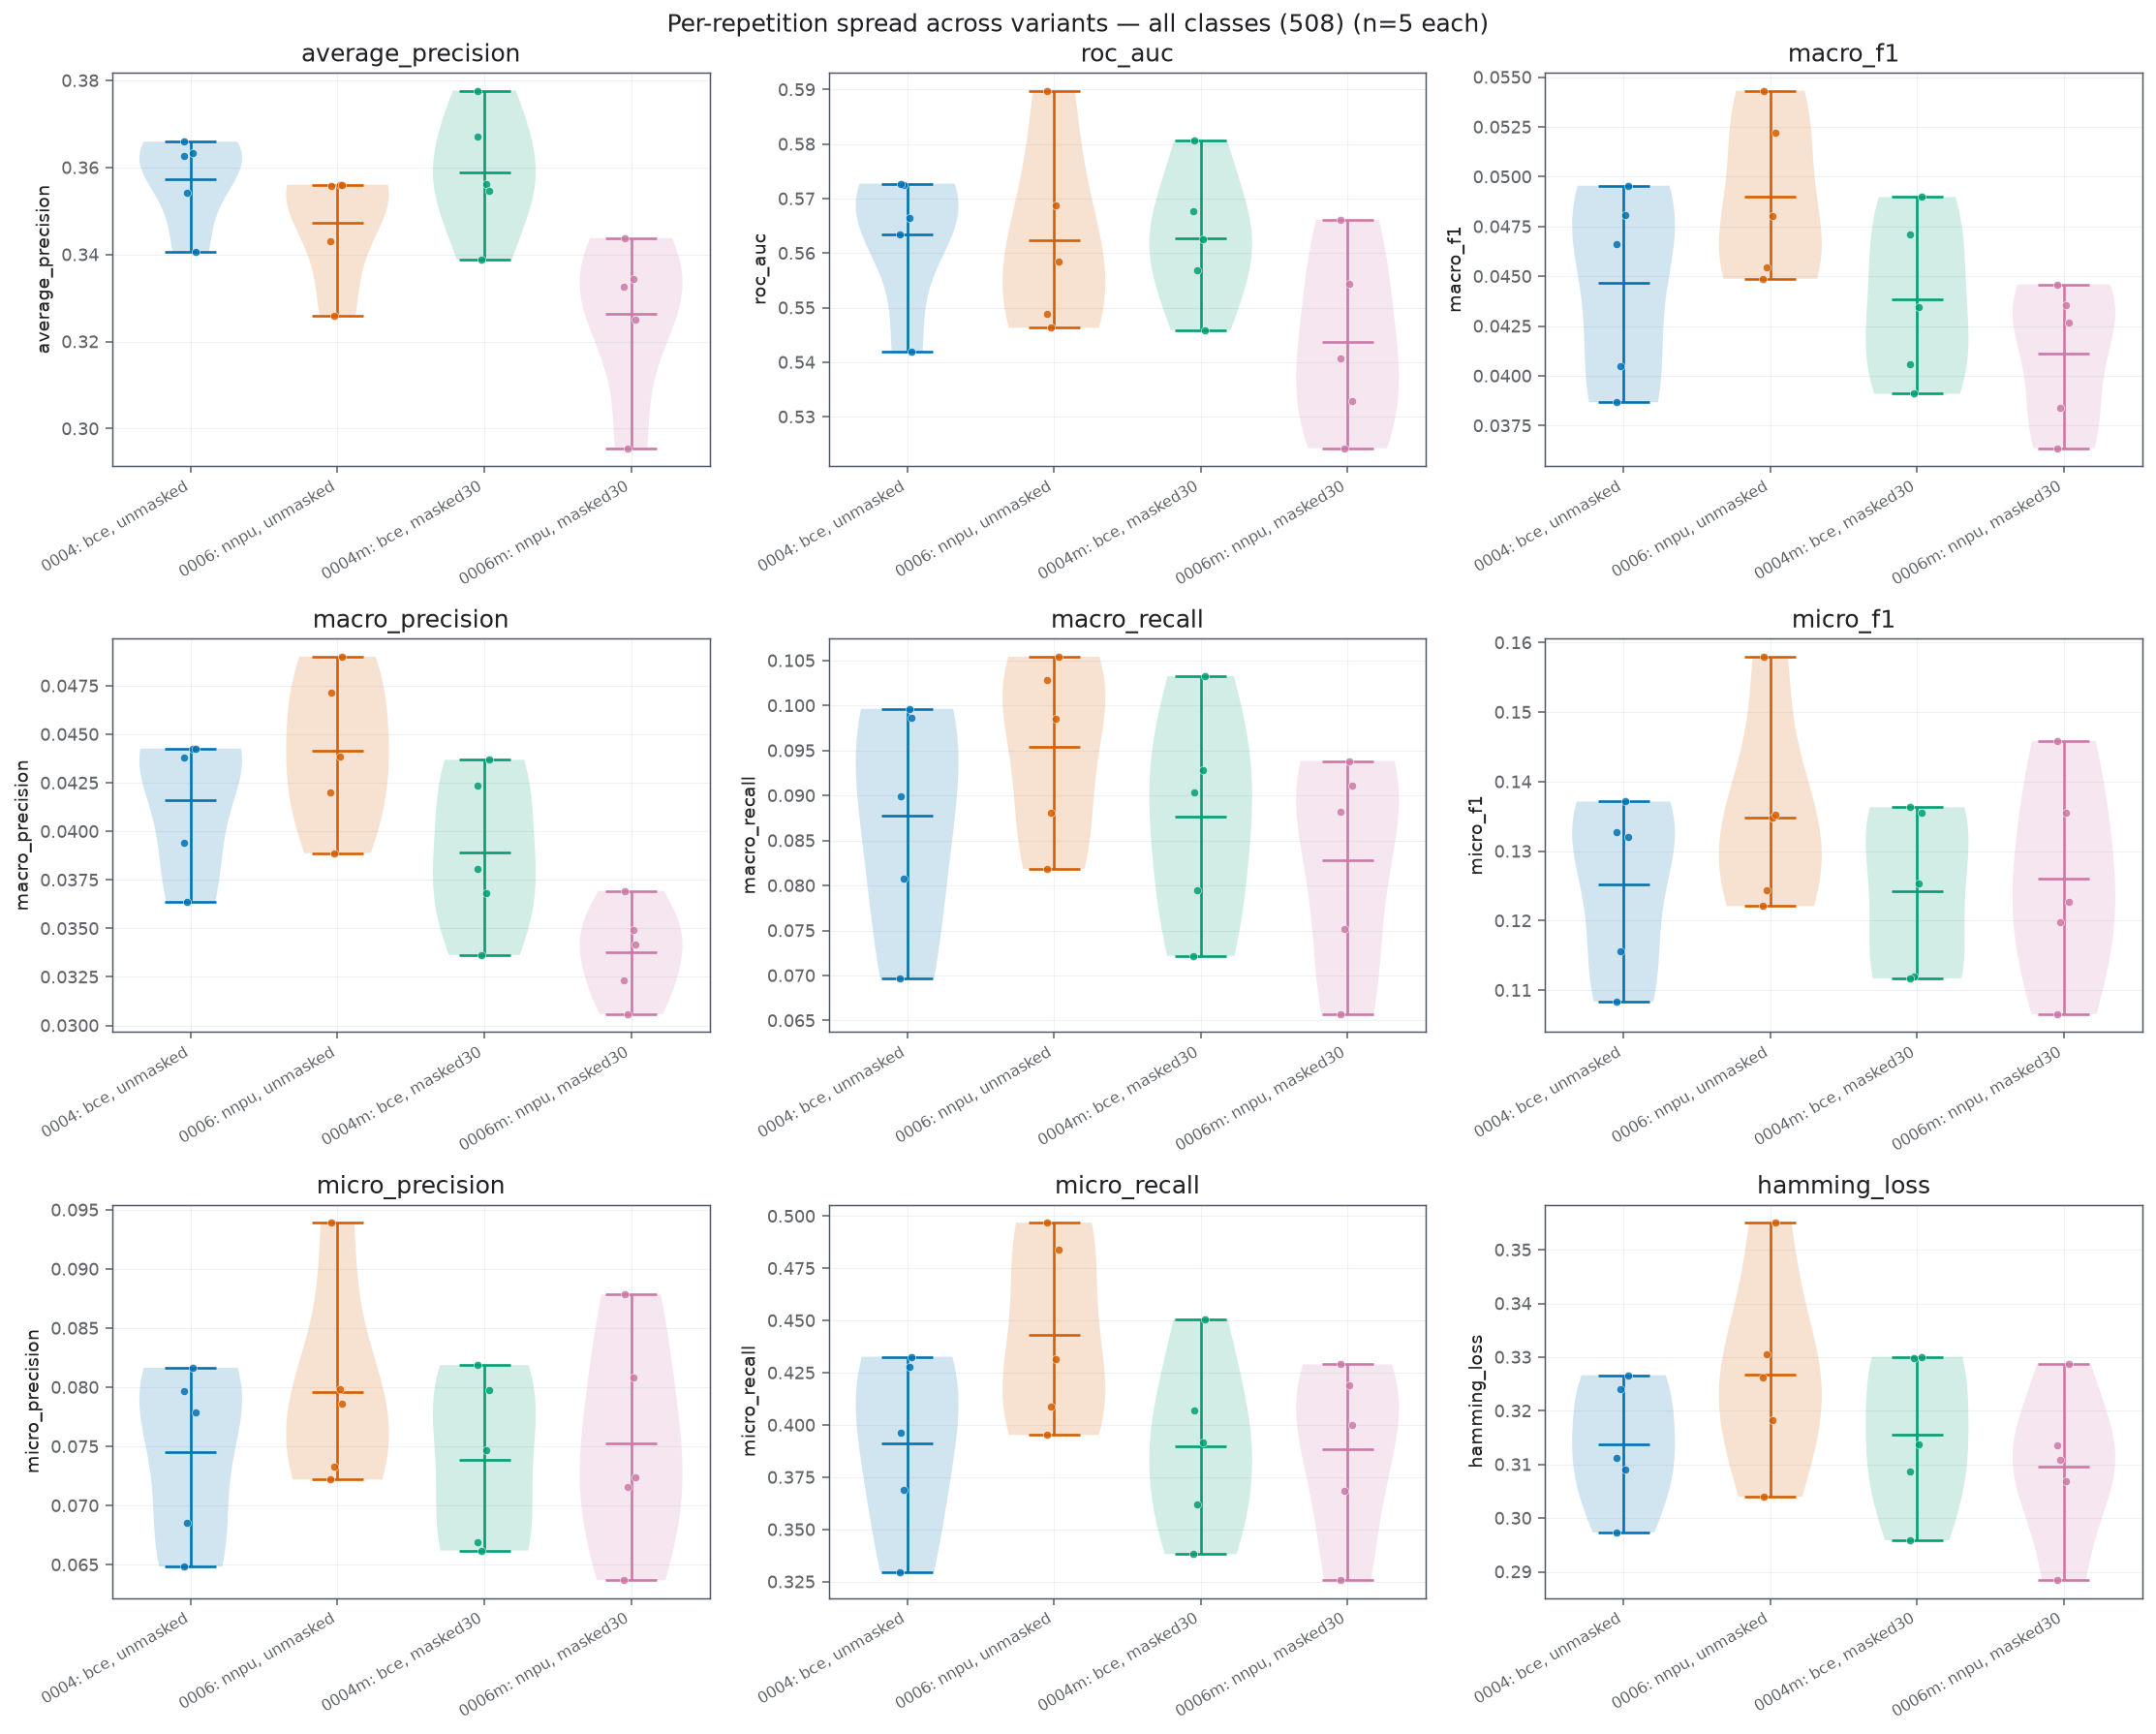

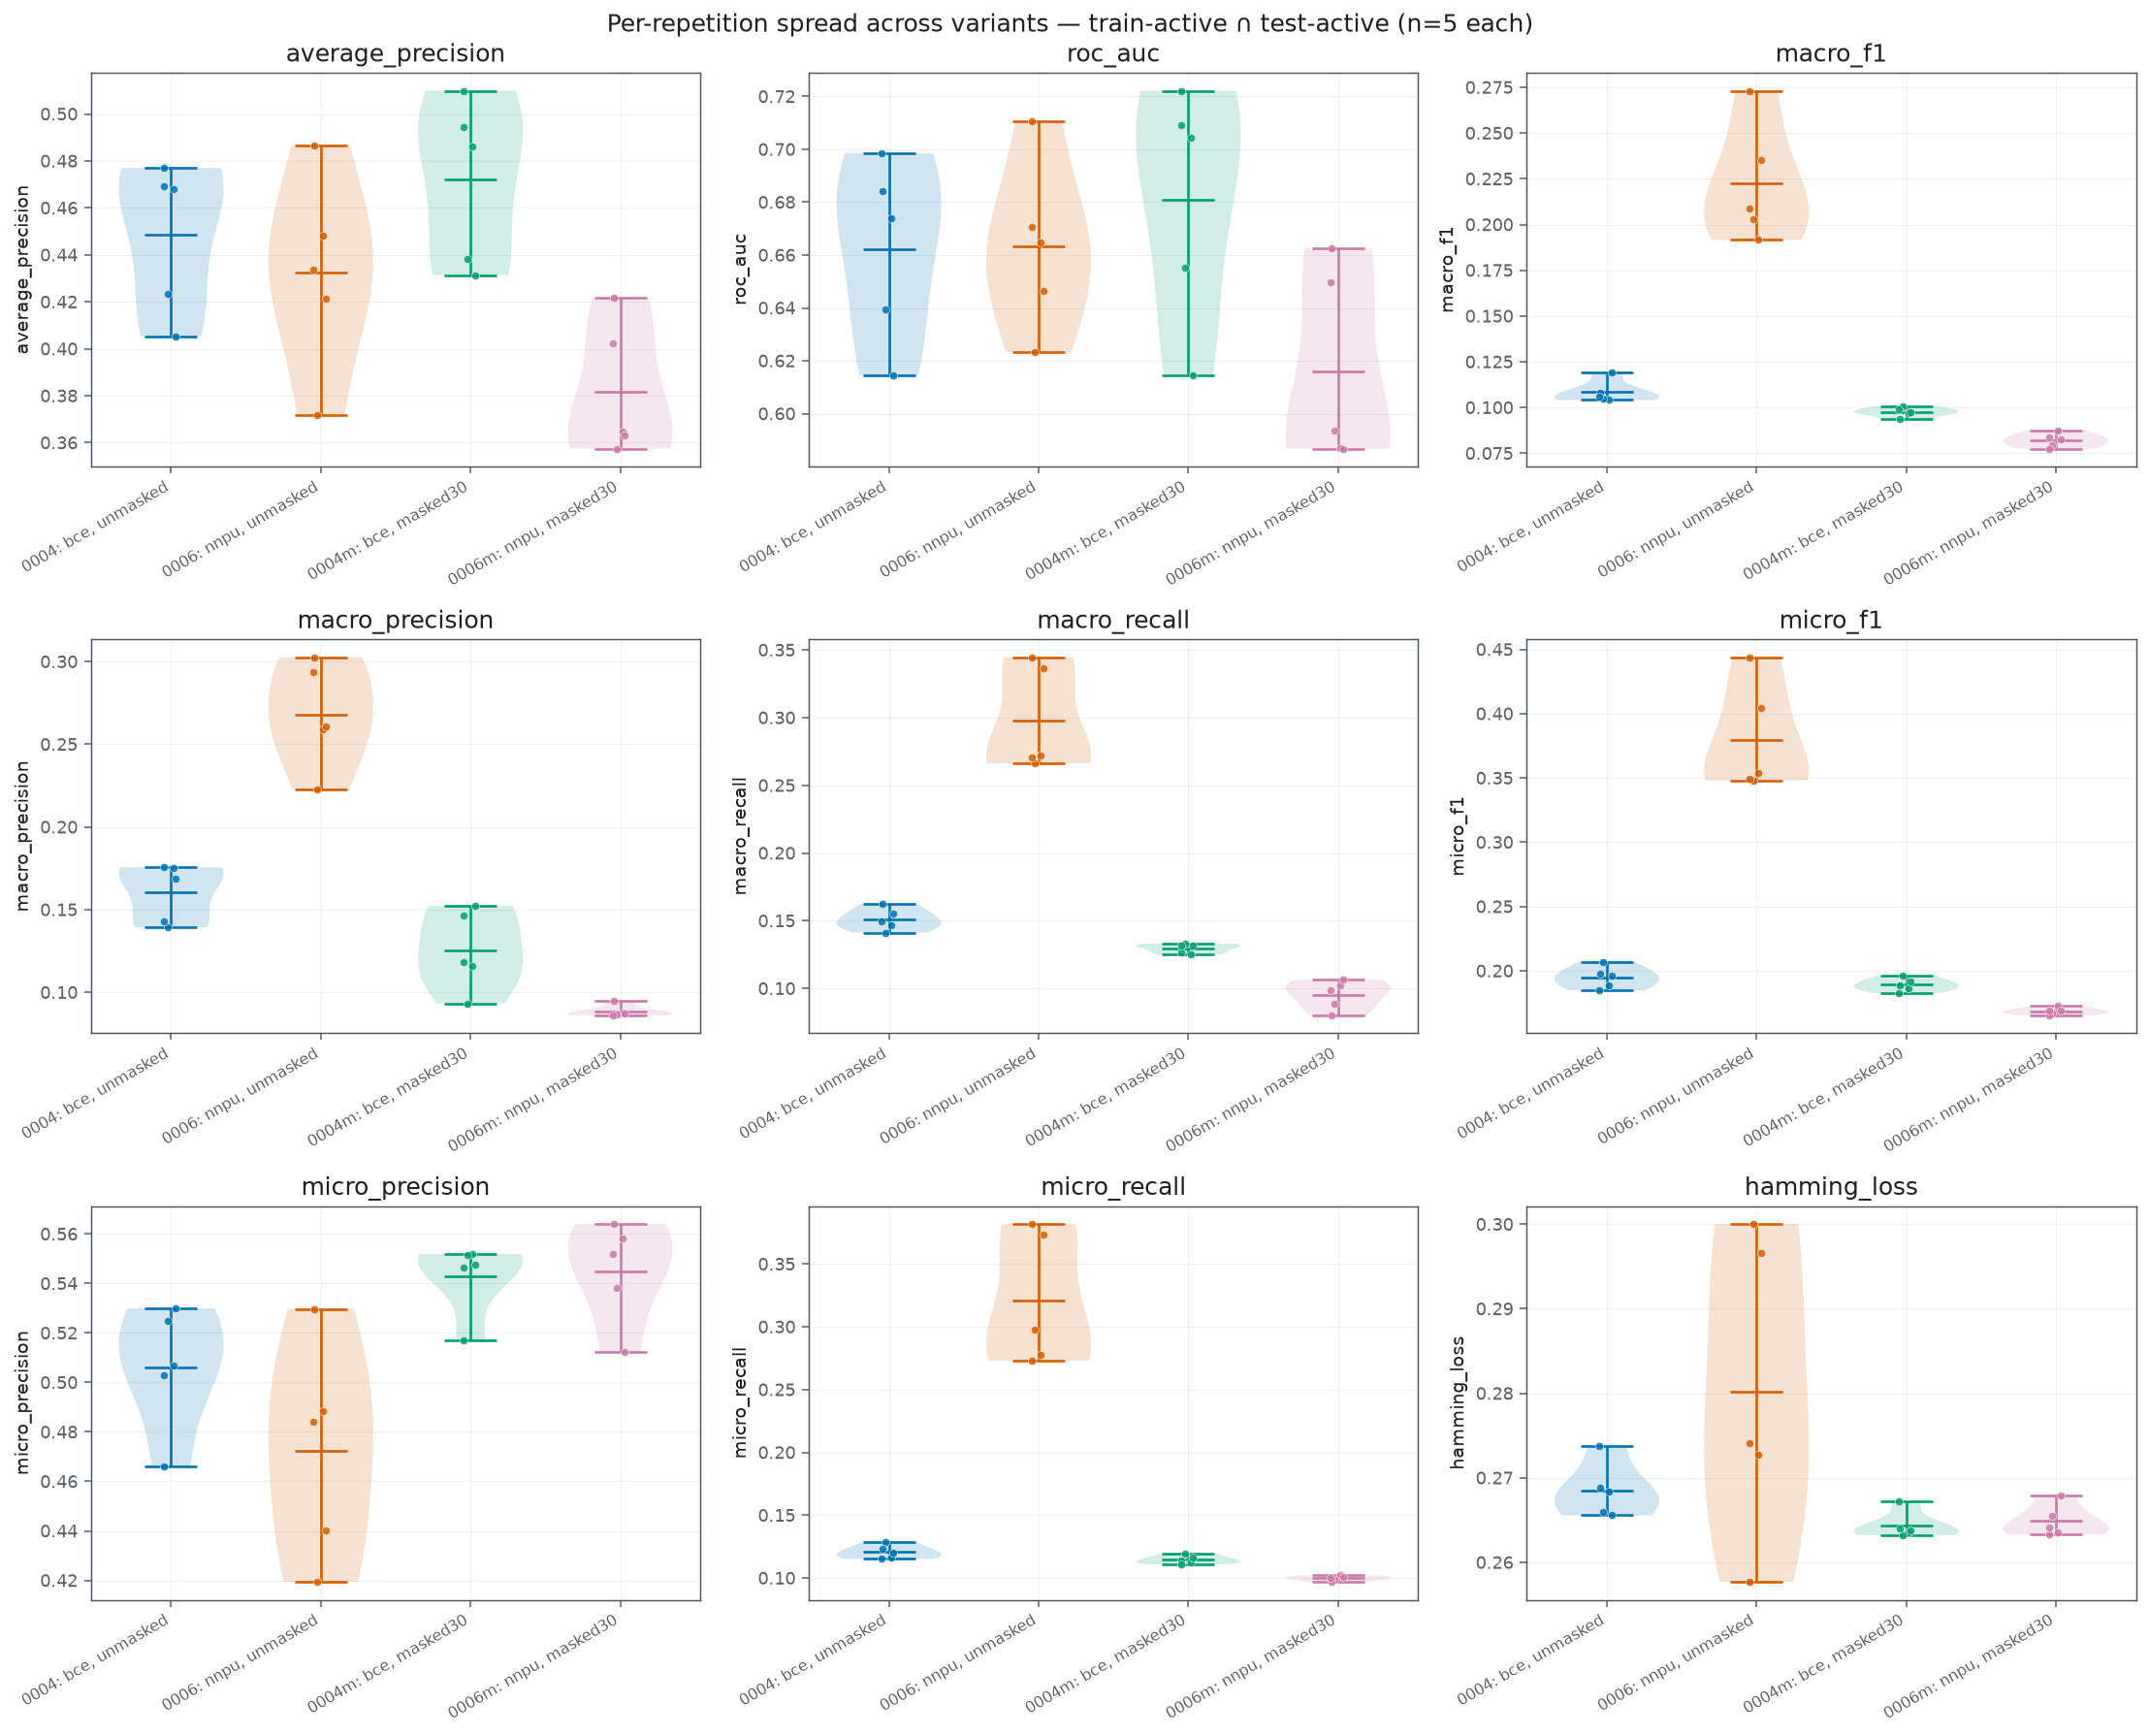

In [8]:
distribution_metric_names = [name for name in unique_metric_columns if name != "hamming_loss_baseline_positive_rate"]
variants = list(VARIANT_SPECS)

for scope_name in (ALL_CLASSES_SCOPE, FAIR_SCOPE):
    scoped_frame = aggregate_frame[aggregate_frame["scope"] == scope_name]
    figure, axes = plt.subplots(3, 3, figsize=(16.0, 13.0), dpi=theme.figure_dpi)
    for axis, metric_name in zip(axes.flat, distribution_metric_names):
        for index, variant in enumerate(variants):
            values = scoped_frame.loc[scoped_frame["variant"] == variant, metric_name].to_numpy()
            plot_violin_with_points(values, position=index, ax=axis, width=0.7, color=theme.color_for_model(variant, index))
        axis.set_xticks(range(len(variants)))
        axis.set_xticklabels([VARIANT_SHORT_LABELS[variant] for variant in variants], rotation=30, ha="right", fontsize=8)
        axis.set(ylabel=metric_name, title=metric_name)
        axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    figure.suptitle(f"Per-repetition spread across variants — {scope_name} (n=5 each)", fontsize=13)
    figure.tight_layout()

## Does masking widen or narrow the nnPU-vs-BCE gap? Paired comparison + seed-noise null

### Methodology
#### Theoretical
- The question this notebook exists to answer: `delta_unmasked = AP(0006) -
  AP(0004)` (nnPU's advantage over BCE without masking) vs. `delta_masked =
  AP(0006_masked30) - AP(0004_masked30)` (the same, with 30% of train positives
  hidden). If nnPU's non-negative correction is doing what it is designed for, the
  masked condition (fewer confirmed positives, more of the "unlabeled" mass is
  secretly positive) should be exactly where nnPU's advantage over BCE grows, i.e.
  `interaction = delta_masked - delta_unmasked` should be positive and should clear
  a seed-noise null.
- Uses `average_precision` in the fair scope (the metric this project's methodology
  treats as primary — non-thresholded, per rule 1) throughout.

#### Implementation
- Within-variant null: all $\binom{5}{2}=10$ repetition-pair absolute differences
  in fair-scope `average_precision`, per variant (same convention as
  `part_5`/`part_6`/`part_7`/`part_9`).
- `delta_unmasked`/`delta_masked` computed from `aggregate_frame`'s fair-scope means
  across the 5 repetitions; each checked against `max(null_mean(bce),
  null_mean(nnpu))` for its own pair. `interaction = delta_masked - delta_unmasked`
  is checked against the largest of all four variants' own within-variant nulls
  (the most conservative choice, since there is no direct null distribution for a
  difference-of-differences).

### Notes


In [9]:
from itertools import combinations

fair_ap_frame = aggregate_frame[aggregate_frame["scope"] == FAIR_SCOPE]

null_rows = []
for variant in VARIANT_SPECS:
    values = fair_ap_frame.loc[fair_ap_frame["variant"] == variant, "average_precision"].to_numpy()
    reps = fair_ap_frame.loc[fair_ap_frame["variant"] == variant, "repetition"].to_numpy()
    for (i, value_a), (j, value_b) in combinations(zip(reps, values), 2):
        null_rows.append({"variant": variant, "rep_pair": f"{i}-{j}", "abs_diff": abs(value_a - value_b)})
null_frame = pd.DataFrame(null_rows)
null_summary = null_frame.groupby("variant")["abs_diff"].agg(["mean", "std", "min", "max"])
print("within-variant |rep_i - rep_j| null (fair-scope average_precision):")
print(null_summary)
print()

variant_means = fair_ap_frame.groupby("variant")["average_precision"].mean()
delta_unmasked = variant_means["0006"] - variant_means["0004"]
delta_masked = variant_means["0006_masked30"] - variant_means["0004_masked30"]
interaction = delta_masked - delta_unmasked

null_unmasked = max(null_summary.loc["0004", "mean"], null_summary.loc["0006", "mean"])
null_masked = max(null_summary.loc["0004_masked30", "mean"], null_summary.loc["0006_masked30", "mean"])
null_interaction = max(null_summary["mean"])

print(f"delta_unmasked (nnpu - bce, no masking):    {delta_unmasked:+.4f} (signal/null = {abs(delta_unmasked) / null_unmasked:.2f})")
print(f"delta_masked   (nnpu - bce, 30% masked):    {delta_masked:+.4f} (signal/null = {abs(delta_masked) / null_masked:.2f})")
print(f"interaction    (delta_masked - delta_unmasked): {interaction:+.4f} (signal/null = {abs(interaction) / null_interaction:.2f})")

comparison_frame = pd.DataFrame([
    {"quantity": "delta_unmasked (0006-0004)", "value": delta_unmasked, "larger_null": null_unmasked, "signal_over_null": abs(delta_unmasked) / null_unmasked},
    {"quantity": "delta_masked (0006_masked30-0004_masked30)", "value": delta_masked, "larger_null": null_masked, "signal_over_null": abs(delta_masked) / null_masked},
    {"quantity": "interaction (delta_masked - delta_unmasked)", "value": interaction, "larger_null": null_interaction, "signal_over_null": abs(interaction) / null_interaction},
])
comparison_frame

within-variant |rep_i - rep_j| null (fair-scope average_precision):
                   mean       std       min       max
variant                                              
0004           0.037857  0.026384  0.001470  0.071558
0004_masked30  0.042601  0.026740  0.007015  0.078495
0006           0.051269  0.030927  0.012194  0.114738
0006_masked30  0.033518  0.023553  0.001606  0.064119

delta_unmasked (nnpu - bce, no masking):    -0.0163 (signal/null = 0.32)
delta_masked   (nnpu - bce, 30% masked):    -0.0902 (signal/null = 2.12)
interaction    (delta_masked - delta_unmasked): -0.0739 (signal/null = 1.44)


,quantity,value,larger_null,signal_over_null
0,delta_unmasked (0006-0004),-0.016296,0.051269,0.317851
1,delta_masked (0006_masked30-0004_masked30),-0.090221,0.042601,2.117841
2,interaction (delta_masked - delta_unmasked),-0.073926,0.051269,1.441923


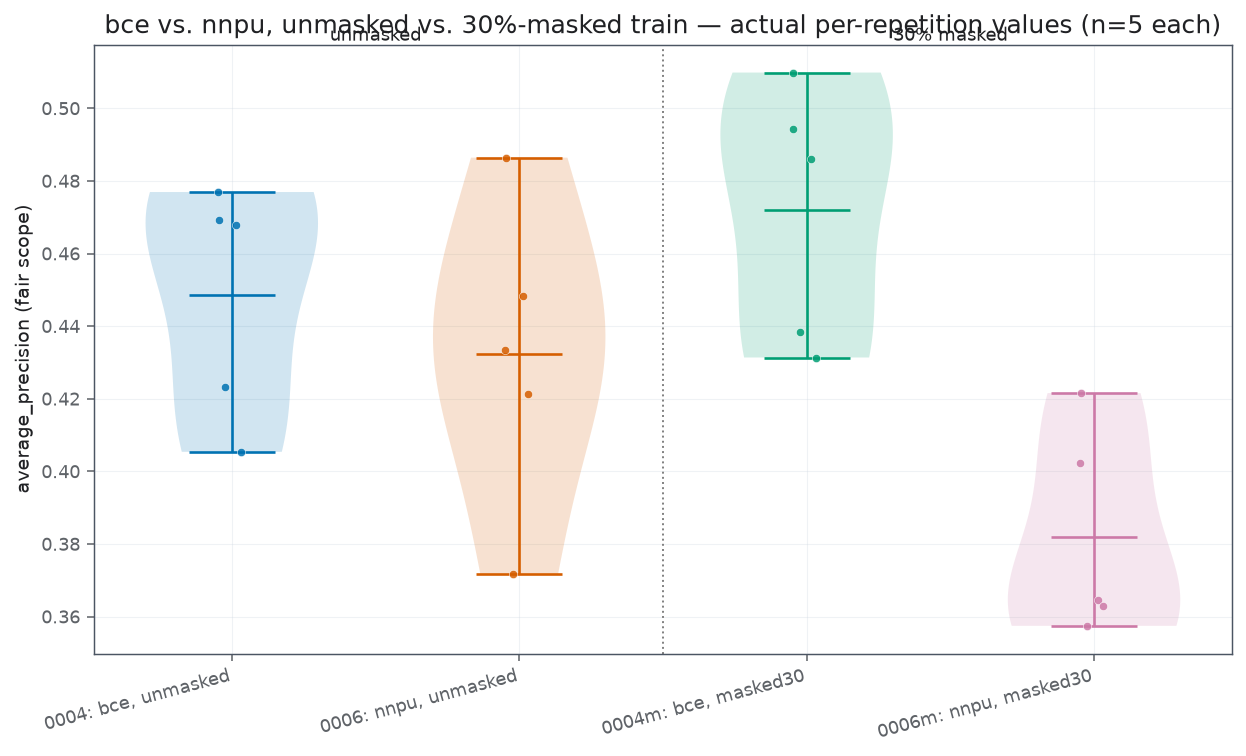

In [10]:
figure, axis = plt.subplots(figsize=(9.0, 5.5), dpi=theme.figure_dpi)
variants = list(VARIANT_SPECS)
for index, variant in enumerate(variants):
    values = fair_ap_frame.loc[fair_ap_frame["variant"] == variant, "average_precision"].to_numpy()
    plot_violin_with_points(values, position=index, ax=axis, width=0.6, color=theme.color_for_model(variant, index))
axis.axvline(1.5, color="grey", linestyle=":", linewidth=1)
axis.text(0.5, axis.get_ylim()[1], "unmasked", ha="center", va="bottom", fontsize=9)
axis.text(2.5, axis.get_ylim()[1], "30% masked", ha="center", va="bottom", fontsize=9)
axis.set_xticks(range(len(variants)))
axis.set_xticklabels([VARIANT_SHORT_LABELS[variant] for variant in variants], rotation=15, ha="right")
axis.set(ylabel="average_precision (fair scope)", title="bce vs. nnpu, unmasked vs. 30%-masked train — actual per-repetition values (n=5 each)")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

In [11]:
output_rows = []
for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    for _, row in aggregate_frame[aggregate_frame["variant"] == variant].iterrows():
        for metric_name in unique_metric_columns:
            output_rows.append({
                "campaign": campaign_id, "variant": variant, "repetition": row["repetition"],
                "scope": row["scope"], "metryka": metric_name, "wartość": row[metric_name],
            })

masking_protocol_frame = pd.DataFrame(output_rows)
masking_protocol_frame.to_csv(RESULTS_DIRECTORY / "masking_protocol.csv", index=False)
print(f"wrote {RESULTS_DIRECTORY / 'masking_protocol.csv'} ({len(masking_protocol_frame)} rows)")

wrote assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results/masking_protocol.csv (400 rows)


## Notes for the next pass

**Headline: masking hurts nnPU's relative standing, the opposite of the task's
stated hypothesis.** In the fair scope (`train-active ∩ test-active`, 31/508
classes; masking removed zero classes from the train-active set — 204/508 in both
the masked and unmasked campaigns):

| variant | fair-scope AP | vs. unmasked counterpart |
|---|---|---|
| `0004` (bce, unmasked) | 0.4486 | — |
| `0006` (nnpu, unmasked) | 0.4323 | `delta_unmasked` = -0.0163 (signal/null 0.32 — **not** detectable) |
| `0004_masked30` (bce, 30% masked) | 0.4721 | vs. `0004`: +0.0235 |
| `0006_masked30` (nnpu, 30% masked) | 0.3818 | vs. `0006`: -0.0505 |

- **Without masking, bce and nnpu are statistically indistinguishable** on
  fair-scope AP (signal/null 0.32) — consistent with `part_13`'s equivalent finding
  on the unmasked pair.
- **With 30% of train positives masked, nnpu is measurably worse than bce**
  (`delta_masked` = -0.0902, signal/null **2.12** — clears the null comfortably).
  `bce` actually *improved* slightly under masking (0.449 → 0.472); `nnpu` *degraded*
  substantially (0.432 → 0.382).
- **The interaction is real and negative**: `interaction` = -0.0739, signal/null
  **1.44** — masking measurably widens nnPU's disadvantage relative to bce, it does
  not narrow it. The task's stated hypothesis (nnPU's non-negative correction should
  make it *more* robust than bce when more positives are hidden) is not supported by
  this data — if anything, the data points the other way.
- Speculative, not verified here: `NNPUMultiLabelLoss`'s prior estimate
  (`prior_method="scaled_train_observed"`) is computed from the *masked* train set's
  observed positive rate, so masking 30% of positives directly lowers the estimated
  prior $\pi_c$ used in the non-negative correction — if the correction's clamp
  activation or magnitude is sensitive to an underestimated prior, that could explain
  the degradation mechanically rather than reflecting anything about robustness to
  unlabeled positives per se. Checking `π_c` before vs. after masking (same method as
  `part_8`'s clamp diagnostics) would directly test this and is the natural next
  step, not done in this notebook.
- Pipeline check passed: `test` targets and mask are byte-identical between the
  masked and unmasked campaigns, confirming masking only touched `train` as intended
  and this comparison is valid.
